In [35]:
# Standard python imports
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.interpolate import interp1d
import configparser
from scipy.signal import windows
from scipy.linalg import toeplitz
from scipy.fft import fft, ifft
from scipy.signal import butter, filtfilt, decimate
import os
import errno

# LVC-specific imports
import pyRing.waveform as wf
from pyRing.utils import *
from lalinference.imrtgr.nrutils import *
from pyRing.inject_signal import inject_ringdown_signal
from pyRing.utils import compute_SNR_FD, compute_SNR_TD, project_python_wrapper

from lalinference                import DetFrameToEquatorial, EquatorialToDetFrame
from lalinference.imrtgr.nrutils import bbh_final_mass_projected_spins, bbh_final_spin_projected_spins, bbh_Kerr_trunc_opts
import lal, lalsimulation as lalsim


import bilby
from bilby.core.utils import nfft
from bilby.gw.utils import optimal_snr_squared
from bilby.gw.detector.psd import PowerSpectralDensity
from bilby.core import utils

def damped_sinusoid(time, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
    waveform1 = np.zeros(len(time), dtype=complex)
    waveform2 = np.zeros(len(time), dtype=complex)

    A1 = A1
    A2 = A2
    w1 = (2*np.pi*f1 + 1j / tau1)
    w2 = (2*np.pi*f2 + 1j / tau2)

    tidx = time >= geocent_time

    waveform1[tidx] = A1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
    waveform2[tidx] = A2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

    total_waveform = waveform1 + waveform2

    plus = total_waveform.real
    cross = - total_waveform.imag

    return {"plus": plus, "waveform1": waveform1.real, "waveform2": waveform2.real}

def toy_model_of_two_QNMs(time, A, alpha, f1, f2, tau1, tau2, phiA, phialpha, geocent_time):

        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w1 - w2
    
        tidx = time >= geocent_time

        amp_1 = A / delta_w
        amp_2 = - A / delta_w * (1 + delta_w * alpha*np.exp(1j * phialpha))

        waveform1[tidx] = amp_1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phiA)
        waveform2[tidx] = amp_2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phiA)
        total_waveform = waveform1 + waveform2

        plus = total_waveform.real
        cross = - total_waveform.imag
    
        return {"plus": plus, "waveform1": waveform1.real, "waveform2": waveform2.real}

def compute_covariance_matrix_from_psd(psd, srate, signal_duration):
    dt = 1.0 / srate
    noise_seglen = int(1 * srate)
    signal_seglen = int(signal_duration * srate)
    freqs_from_file, psd_from_file = psd[:,0], psd[:,1]

    f_min_psd = 20.5
    f_max_psd = 2038.0

    psd_from_file   = psd_from_file[  freqs_from_file > f_min_psd]
    freqs_from_file = freqs_from_file[freqs_from_file > f_min_psd]
    psd_from_file   = psd_from_file[  freqs_from_file < f_max_psd]
    freqs_from_file = freqs_from_file[freqs_from_file < f_max_psd]

    psd_from_file_interp           = interp1d(freqs_from_file, psd_from_file, fill_value='extrapolate', bounds_error=False)
    freqs_default                  = np.fft.rfftfreq(noise_seglen, d = dt)
    df_default                     = np.diff(freqs_default)[0]
    psd_interp                     = psd_from_file_interp(freqs_default)
    psd_interp                     = np.abs(psd_interp)

    ACF = 0.5*np.real(np.fft.irfft(psd_interp*df_default))*noise_seglen
    ACF_signal = ACF[:signal_seglen]
    Covariance_matrix_signal = toeplitz(ACF_signal)
    epsilon = 1e-9 * np.max(np.diag(Covariance_matrix_signal))
    Covariance_matrix_signal += epsilon * np.eye(signal_seglen)
    return Covariance_matrix_signal

def inject_pyring_waveform(config_file_pyring, plot_EP=False):

    config_ini_pyring = configparser.ConfigParser()
    config_ini_pyring.read(config_file_pyring)
    if not os.path.exists(config_file_pyring):
        raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), config_file_pyring)
    config_injection_pyring = config_ini_pyring['Injection']
    config_input_pyring = config_ini_pyring['input']
    
    srate   = 4096
    # signal_duration = 410 / srate
    signal_duration = 1.0
    pre_trigger_duration = signal_duration / 2.0
    try: 
        trigger_time = float(config_injection_pyring['t'])
    except :
        trigger_time = float(config_injection_pyring['t_t_0'])
    times   = np.linspace(trigger_time-pre_trigger_duration, trigger_time+signal_duration-pre_trigger_duration, int(srate*signal_duration))

    if plot_EP:
        if config_input_pyring['template'] != 'EP_waveform':
            plot_EP = False
            print("Warning: EP waveform can only be plotted when the template is set to 'EP_waveform'.")

    if config_input_pyring['injection-approximant'] == 'Damped-sinusoids':
        A1 = float(config_injection_pyring['A_t_0'])
        A2 = float(config_injection_pyring['A_t_1'])
        f1 = float(config_injection_pyring['f_t_0'])
        f2 = float(config_injection_pyring['f_t_1'])
        tau1 = float(config_injection_pyring['tau_t_0'])
        tau2 = float(config_injection_pyring['tau_t_1'])
        phi1 = float(config_injection_pyring['phi_t_0'])
        phi2 = float(config_injection_pyring['phi_t_1'])

        parameters = {
                    'A': {'t': [A1, A2]},
                    'f': {'t': [f1, f2]},
                    'tau': {'t': [tau1, tau2]},
                    'phi': {'t': [phi1, phi2]},
                    'psi': float(config_injection_pyring['psi']),
                    'ra': float(config_injection_pyring['ra']),
                    'dec': float(config_injection_pyring['dec']),
                    't': {'t': [float(config_injection_pyring['t_t_0']), float(config_injection_pyring['t_t_1'])]},
                    }
        model = wf.Damped_sinusoids(
                                parameters['A'],
                                parameters['f'],
                                parameters['tau'],
                                parameters['phi'],
                                parameters['t']
                                )

        waveform_for_plot = damped_sinusoid(times, A1, A2, f1, f2, tau1, tau2, phi1, phi2, trigger_time)
        
        w1 = 2 * np.pi * f1 + 1j / tau1
        w2 = 2 * np.pi * f2 + 1j / tau2
        delta_w = w1 - w2
        bilby.core.utils.logger.info('A1 : {}'.format(A1))
        bilby.core.utils.logger.info('A2 : {}'.format(A2))
        bilby.core.utils.logger.info('w1 : {}'.format(w1))
        bilby.core.utils.logger.info('w2 : {}'.format(w2))
        bilby.core.utils.logger.info('delta_w : {}'.format(delta_w))
        bilby.core.utils.logger.info('|delta_w/w1| : {}'.format(np.abs(delta_w / w1)))
        bilby.core.utils.logger.info('phi1 : {}'.format(phi1))
        bilby.core.utils.logger.info('phi2 : {}'.format(phi2))

        print("\ninjection parameters:")
        for key, value in parameters.items():
            print(f"  {key}: {value}")

    elif config_input_pyring['injection-approximant'] == 'toy_model_of_two_QNMs':
        A = float(config_injection_pyring['A'])
        alpha = float(config_injection_pyring['alpha'])
        w1 = (2 * np.pi * float(config_injection_pyring['f1']) + 1j / float(config_injection_pyring['tau1']))
        w2 = (2 * np.pi * float(config_injection_pyring['f2']) + 1j / float(config_injection_pyring['tau2']))
        delta_w = w1 - w2
        A1_complex = A / delta_w
        A1 = np.abs(A1_complex)
        phi1_from_amp = np.angle(A1_complex)
        phi1 = float(config_injection_pyring['phiA']) + phi1_from_amp
        A2_complex = - A * (1 + alpha * np.exp(1j * float(config_injection_pyring['phialpha'])) * delta_w) / delta_w
        A2 = np.abs(A2_complex)
        phi2_from_amp = np.angle(A2_complex)
        phi2 = float(config_injection_pyring['phiA']) + phi2_from_amp

        parameters = {
                    'A'     : float(config_injection_pyring['A']),
                    'alpha' : float(config_injection_pyring['alpha']),
                    'f1'    : float(config_injection_pyring['f1']),
                    'f2'    : float(config_injection_pyring['f2']),
                    'tau1' : float(config_injection_pyring['tau1']),
                    'tau2' : float(config_injection_pyring['tau2']),
                    'phiA' : float(config_injection_pyring['phiA']),
                    'phialpha' : float(config_injection_pyring['phialpha']),
                    'psi' : float(config_injection_pyring['psi']),
                    'ra'  : float(config_injection_pyring['ra']),
                    'dec' : float(config_injection_pyring['dec']),
                    't'   : float(config_injection_pyring['t']),
                    }
        model = wf.toy_model_of_two_QNMs(
                                parameters['A'],
                                parameters['alpha'],
                                parameters['f1'],
                                parameters['f2'],
                                parameters['tau1'],
                                parameters['tau2'],
                                parameters['phiA'],
                                parameters['phialpha'],
                                parameters['t'],
                                )

        waveform_for_plot = toy_model_of_two_QNMs(times, A, alpha, float(config_injection_pyring['f1']), float(config_injection_pyring['f2']), float(config_injection_pyring['tau1']), float(config_injection_pyring['tau2']), float(config_injection_pyring['phiA']), float(config_injection_pyring['phialpha']), trigger_time)

        print("\ninjection parameters:")
        for key, value in parameters.items():
            print(f"  {key}: {value}")        

        if plot_EP:
            C = A * alpha
            D = A
            f = float(config_injection_pyring['f1'])
            tau = float(config_injection_pyring['tau1'])
            phiC = np.angle(- np.exp(1j * (float(config_injection_pyring['phiA']) + float(config_injection_pyring['phialpha']))))
            phiD = float(config_injection_pyring['phiA'])
            EP_parameters = {
                            'C': C,
                            'D': D,
                            'f': f,
                            'tau': tau,
                            'phiC': phiC,
                            'phiD': phiD,
                            'psi': float(config_injection_pyring['psi']),
                            'ra': float(config_injection_pyring['ra']),
                            'dec': float(config_injection_pyring['dec']),
                            't': float(config_injection_pyring['t']),
                            }
            EP_model = wf.EP_waveform(
                        EP_parameters['C']  ,
                        EP_parameters['D']  ,
                        EP_parameters['f']  ,
                        EP_parameters['tau'],
                        EP_parameters['phiC'],
                        EP_parameters['phiD'],
                        EP_parameters['t'],
                        )
            _, _, _, hp_EP, hc_EP = EP_model.waveform(times)
            print("\nEP waveform parameters:")
            for key, value in EP_parameters.items():
                print(f"  {key}: {value}")

        bilby.core.utils.logger.info('A1 : {}'.format(A1))
        bilby.core.utils.logger.info('A2 : {}'.format(A2))
        bilby.core.utils.logger.info('alpha : {}'.format(alpha))
        bilby.core.utils.logger.info('w1 : {}'.format(w1))
        bilby.core.utils.logger.info('w2 : {}'.format(w2))
        bilby.core.utils.logger.info('delta_w : {}'.format(delta_w))
        bilby.core.utils.logger.info('|delta_w/w1| : {}'.format(np.abs(delta_w / w1)))
        bilby.core.utils.logger.info('delta_w * alpha : {}'.format(delta_w * alpha))
        bilby.core.utils.logger.info('phi1 : {}'.format(phi1))
        bilby.core.utils.logger.info('phi2 : {}'.format(phi2))

    # Unpack the waveform and ignore vector and scalar modes.
    _, _, _, hp, hc = model.waveform(times)

    plt.style.use('~/research/my_plot_style.style')
    plot_time_start = trigger_time - 0.01
    plot_time_end = trigger_time + 0.03

    if plot_EP:
        plt.figure()
        plt.plot(times, hp, label=r'$h_{+}$', linestyle='-')
        plt.plot(times, hp_EP, label=r'$h_{+}$, EP', linestyle=':')
        plt.xlabel(r'$\mathrm{t \, [s]}$')
        plt.ylabel(r'$\mathrm{Strain}$')
        plt.xlim(plot_time_start, plot_time_end)
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()
    
        plt.figure()
        plt.plot(times, hc, label=r'$h_{\times}$', linestyle='-')
        plt.plot(times, hc_EP, label=r'$h_{\times}$, EP', linestyle=':')
        plt.xlabel(r'$t \, [\mathrm{s}]$')
        plt.ylabel('Strain')
        plt.xlim(plot_time_start, plot_time_end)
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()
    else:
        plt.figure()
        plt.plot(times, hp, label=r'$h_{+}$', linestyle='-')
        plt.plot(times, hc, label=r'$h_{\times}$', linestyle='-')
        plt.xlabel(r'$t \, [\mathrm{s}]$')
        plt.ylabel('Strain')
        plt.xlim(plot_time_start, plot_time_end)
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()
    
    plt.figure()
    plt.plot(times, waveform_for_plot['plus'], label=r'$h_{+}$', linestyle='solid', alpha=1)
    plt.plot(times, waveform_for_plot['waveform1'], label=r'$h_{1}$', linestyle='dashed', alpha=0.7)
    plt.plot(times, waveform_for_plot['waveform2'], label=r'$h_{2}$', linestyle='dotted', alpha=0.7)
    plt.xlabel(r'$t \ \mathrm{[s]}$')
    plt.ylabel('Strain')
    plt.xlim(plot_time_start, plot_time_end)
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

    detectors = ['H1', 'L1', 'V1']

    plt.figure()
    detector_wave_dicts = {}
    for detector in detectors:
        kwargs = {
            'injection-approximant' : config_input_pyring['injection-approximant'],
            'injection-parameters' : parameters,
            'ref-det' : detector,
            'sky-frame' : 'equatorial',
            'injection-scaling' : 1.0,
        }
        wave, time_axis_waveform = inject_ringdown_signal(times=times, triggertime=trigger_time, ifo=detector, print_output=True, **kwargs)
        plt.plot(time_axis_waveform, wave, linestyle='solid', alpha=0.7, label=detector)
        detector_wave_dicts[detector] = {'waveform': wave, 'time_axis': time_axis_waveform}
    plt.xlabel(r'$t \ \mathrm{[s]}$')
    plt.ylabel('Strain')
    plt.xlim(plot_time_start, plot_time_end)
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

    """calculate frequency domain strain"""
    ifos = bilby.gw.detector.InterferometerList(detectors)
    h_plus_fdomain, frequency_array = nfft(time_domain_strain=hp, sampling_frequency=srate)
    h_cross_fdomain, frequency_array = nfft(time_domain_strain=hc, sampling_frequency=srate)
    print(frequency_array.shape, h_plus_fdomain.shape, h_cross_fdomain.shape)

    if plot_EP:
        h_plus_fdomain_EP, frequency_array = nfft(time_domain_strain=hp_EP, sampling_frequency=srate)
        h_cross_fdomain_EP, frequency_array = nfft(time_domain_strain=hc_EP, sampling_frequency=srate)

        plt.figure()
        plt.plot(frequency_array, np.abs(h_plus_fdomain), label=r'$|h_{+}|$', linestyle='-')
        plt.plot(frequency_array, np.abs(h_plus_fdomain_EP), label=r'$|h_{+}|$ (EP)', linestyle=':')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

        plt.figure()
        plt.plot(frequency_array, np.abs(h_cross_fdomain), label=r'$|h_{\times}|$', linestyle='-')
        plt.plot(frequency_array, np.abs(h_cross_fdomain_EP), label=r'$|h_{\times}|$ (EP)', linestyle=':')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

    else:
        plt.figure()
        plt.plot(frequency_array, np.abs(h_plus_fdomain), label=r'$|h_{+}|$', color='crimson', linestyle='dashed')
        plt.plot(frequency_array, np.abs(h_cross_fdomain), label=r'$|h_{\times}|$', color='royalblue', linestyle='solid')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()
    
    """calculate frequency domain response and SNR"""
    for ifo in ifos:
        ifo.frequency_array = frequency_array
        ifo.minimum_frequency = 20.0
        ifo.maximum_frequency = 512
    

    psd_ligo = './asd_files/aLIGO_O4_high_psd.txt'
    psd_virgo = './asd_files/AdV_psd.txt'

    psd = {}
    psd['H1'] = np.loadtxt(psd_ligo)
    psd['L1'] = np.loadtxt(psd_ligo)
    psd['V1'] = np.loadtxt(psd_virgo)

    SNR_pyring = []
    ht_dict_pyring = {}
    SNR_pyring_EP = []
    ht_dict_pyring_EP = {}
    for name, ifo in zip(detectors, ifos):
        detector = lal.cached_detector_by_prefix[ifo.name]
        ref_det    = lal.cached_detector_by_prefix['H1']
        psi        = parameters['psi']
        ra, dec    = parameters['ra'], parameters['dec']
        tM_gps     = lal.LIGOTimeGPS(trigger_time)
        time_delay = lal.ArrivalTimeDiff(detector.location, ref_det.location, ra, dec, tM_gps)

        ht_det = project_python_wrapper(hs=0,
                                        hvx=0, hvy=0,
                                        hp=hp,
                                        hc=hc,
                                        detector=detector,
                                        ra=parameters['ra'],
                                        dec=parameters['dec'],
                                        psi=parameters['psi'],
                                        tgps=trigger_time
                                        )
        
        f_min_bp = 20.5
        f_max_bp = 2038.0
        bb, ab = butter(4, [f_min_bp / (srate / 2.), f_max_bp / (srate / 2.)], btype='band')
        ht_det_filtered = filtfilt(bb, ab, ht_det) # bandpass filter
        ht_dict_pyring[ifo.name] = ht_det_filtered

        CM = compute_covariance_matrix_from_psd(psd[ifo.name], srate, signal_duration)
        inverse_CM = np.linalg.inv(CM)
        SNR = compute_SNR_TD(data=ht_det_filtered, template=ht_det_filtered, weights=inverse_CM)
        SNR_pyring.append(SNR)

        if plot_EP:
            ht_det_EP = project_python_wrapper(hs=0,
                                            hvx=0, hvy=0,
                                            hp=hp_EP,
                                            hc=hc_EP,
                                            detector=detector,
                                            ra=parameters['ra'],
                                            dec=parameters['dec'],
                                            psi=parameters['psi'],
                                            tgps=trigger_time
                                            )
            ht_det_EP_filtered = filtfilt(bb, ab, ht_det_EP)
            ht_dict_pyring_EP[ifo.name] = ht_det_EP_filtered
            SNR_EP = compute_SNR_TD(data=ht_det_EP_filtered, template=ht_det_EP_filtered, weights=inverse_CM)
            SNR_pyring_EP.append(SNR_EP)

    network_SNR = np.sqrt(np.sum(np.array(SNR_pyring)**2.))
    print('--------------------------------')
    print('SNR pyring: {}'.format(SNR_pyring))
    print('network SNR pyring: {}'.format(network_SNR))
    print('--------------------------------')

    if plot_EP:
        network_SNR_EP = np.sqrt(np.sum(np.array(SNR_pyring_EP)**2.))
        print('\n--------------------------------')
        print('SNR pyring (EP): {}'.format(SNR_pyring_EP))
        print('network SNR pyring (EP): {}'.format(network_SNR_EP))
        print('--------------------------------')

    # should be fd waveform for pyring using fft
    detector_wave_fdomain_dicts = {}
    detector_wave_fdomain_dicts_EP = {}
    for name, ifo in zip(detectors, ifos):
        hf_det, frequency_array = nfft(time_domain_strain=ht_dict_pyring[ifo.name], sampling_frequency=srate)
        detector_wave_fdomain_dicts[ifo.name] = {'waveform': hf_det, 'frequency_array': frequency_array}
        if plot_EP:
            hf_det_EP, frequency_array_EP = nfft(time_domain_strain=ht_dict_pyring_EP[ifo.name], sampling_frequency=srate)
            detector_wave_fdomain_dicts_EP[ifo.name] = {'waveform': hf_det_EP, 'frequency_array': frequency_array_EP}

    if plot_EP:
        for ifo in ifos:
            plt.figure()
            plt.plot(detector_wave_fdomain_dicts[ifo.name]['frequency_array'], 2*detector_wave_fdomain_dicts[ifo.name]['frequency_array']**0.5*np.abs(detector_wave_fdomain_dicts[ifo.name]['waveform']), label=ifo.name)
            plt.plot(detector_wave_fdomain_dicts_EP[ifo.name]['frequency_array'], 2*detector_wave_fdomain_dicts_EP[ifo.name]['frequency_array']**0.5*np.abs(detector_wave_fdomain_dicts_EP[ifo.name]['waveform']), label=ifo.name + ' (EP)', linestyle=':')
            plt.xlim(10, 1000)
            plt.xscale('log')
            plt.yscale('log')
            plt.xlabel('Frequency [Hz]')
            plt.ylabel(r'$\mathrm{Strain} \, [1/\sqrt{\mathrm{Hz}}]$')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()
    else:
        plt.figure()
        for ifo in ifos:
            plt.plot(detector_wave_fdomain_dicts[ifo.name]['frequency_array'], 2*detector_wave_fdomain_dicts[ifo.name]['frequency_array']**0.5*np.abs(detector_wave_fdomain_dicts[ifo.name]['waveform']), label=ifo.name)
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\sqrt{\mathrm{Hz}}]$')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    print("\n--- Antenna Pattern Check ---")
    gps_time = trigger_time
    ra = parameters['ra']
    dec = parameters['dec']
    psi = parameters['psi']
    for name, ifo in zip(detectors, ifos):
        det_lal = lal.cached_detector_by_prefix[name]
        gmst = lal.GreenwichMeanSiderealTime(lal.LIGOTimeGPS(gps_time))
        fp_lal, fc_lal = lal.ComputeDetAMResponse(det_lal.response, ra, dec, psi, gmst)
    
        print(f"[{name}]")
        print(f"  LAL   : F+={fp_lal:.4f}, Fx={fc_lal:.4f}")

16:04 bilby INFO    : A1 : 1.1779600567210302e-20
16:04 bilby INFO    : A2 : 1.2291807141543995e-20
16:04 bilby INFO    : w1 : (1264.4143462793452+301.02689574732483j)
16:04 bilby INFO    : w2 : (1173.185927675676+926.8619206753834j)
16:04 bilby INFO    : delta_w : (91.22841860366907-625.8350249280586j)
16:04 bilby INFO    : |delta_w/w1| : 0.4865914775806372
16:04 bilby INFO    : phi1 : 1.4260451441507016
16:04 bilby INFO    : phi2 : -1.8937345400972498



injection parameters:
  A: {'t': [1.1779600567210302e-20, 1.2291807141543995e-20]}
  f: {'t': [201.23779332666524, 186.71833955543468]}
  tau: {'t': [0.0033219623034593474, 0.0010789093582260047]}
  phi: {'t': [1.4260451441507016, -1.8937345400972498]}
  psi: 0.0
  ra: 0.0
  dec: 0.0
  t: {'t': [0.0, 0.0]}


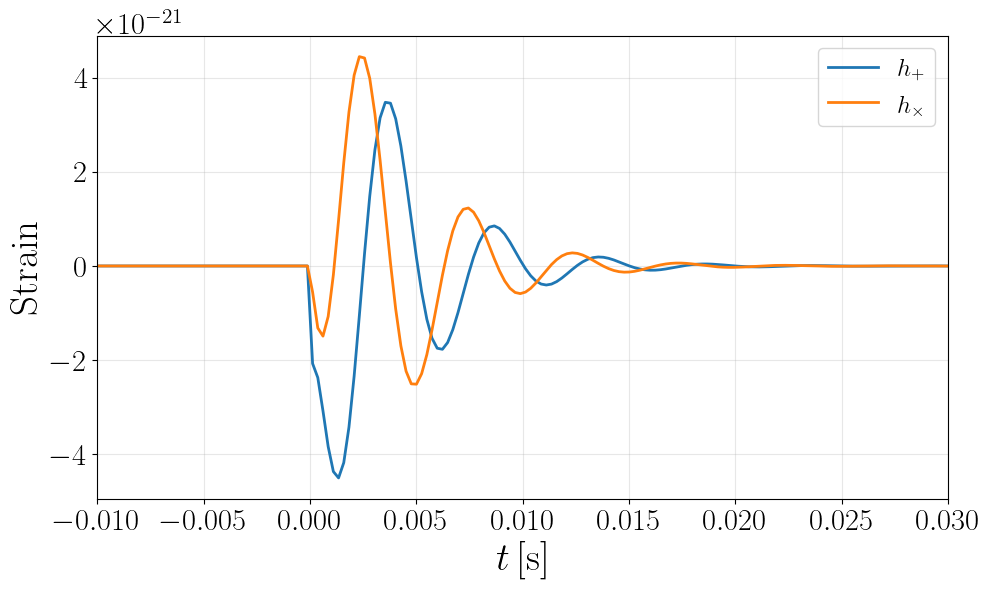

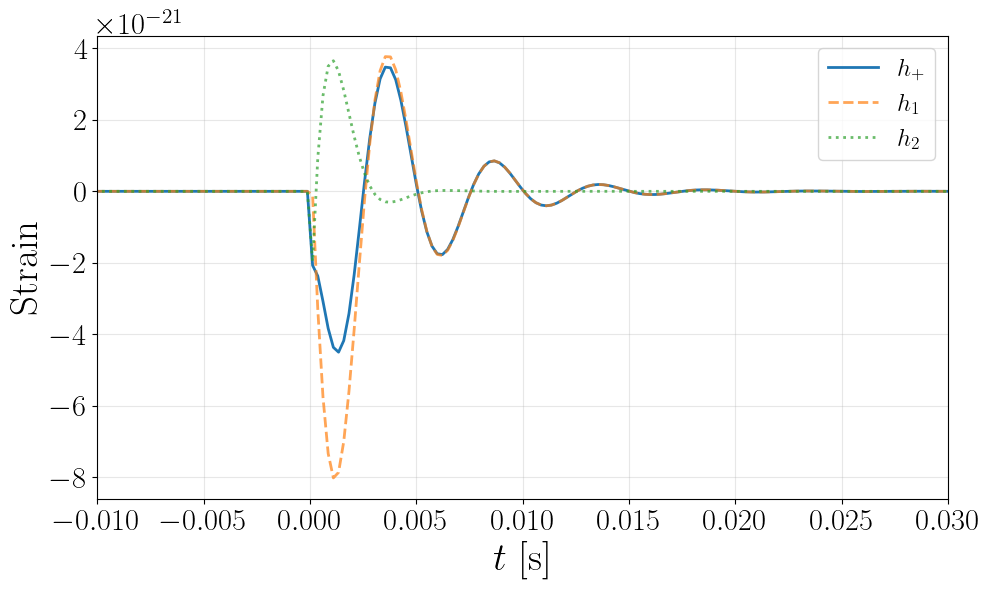

* Injecting the `Damped-sinusoids` waveform model in the H1 detector.
* Injecting the `Damped-sinusoids` waveform model in the L1 detector.
* Injecting the `Damped-sinusoids` waveform model in the V1 detector.


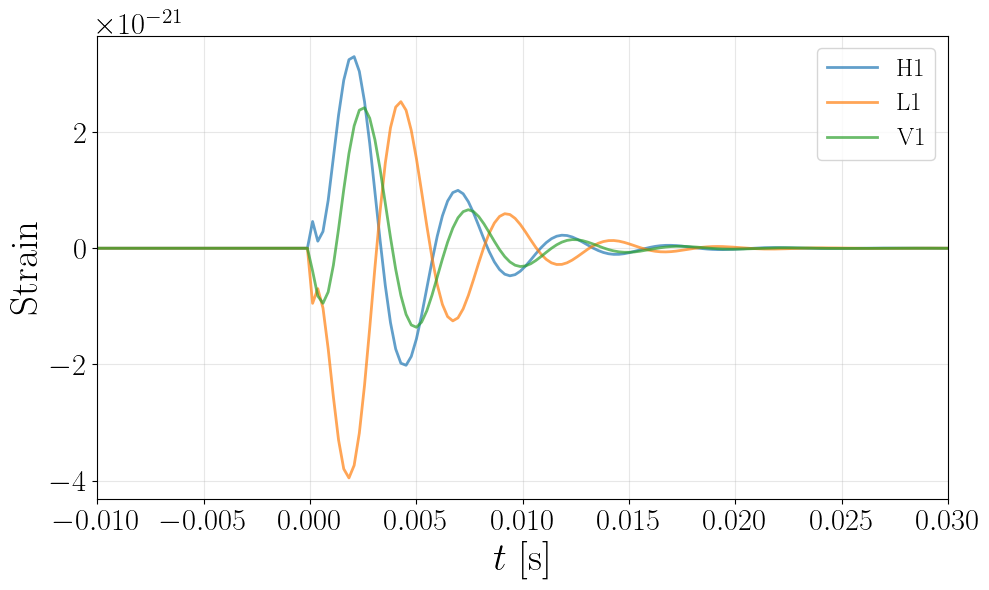

(2049,) (2049,) (2049,)


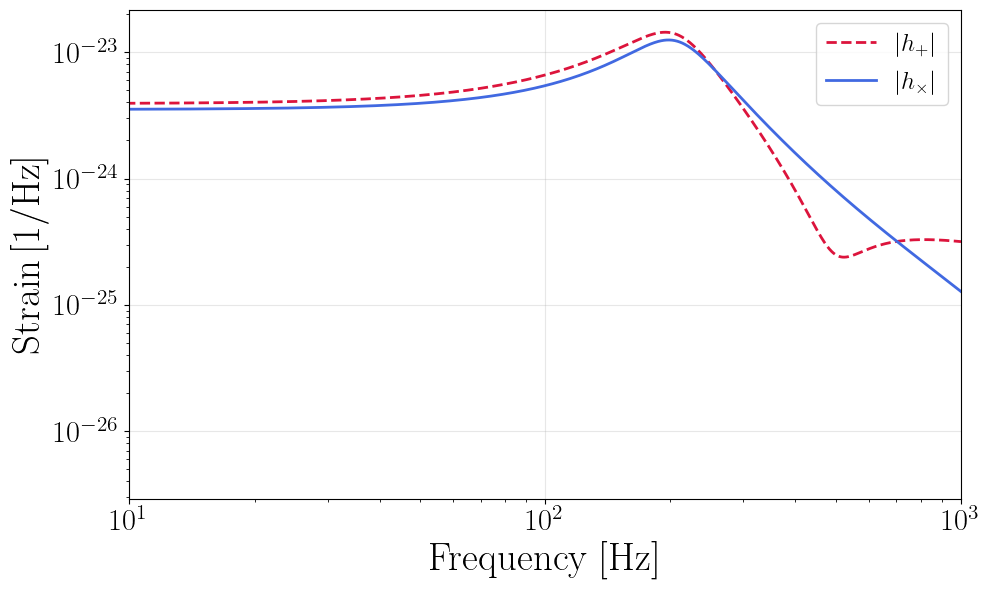

--------------------------------
SNR pyring: [59.05468091464669, 71.72604491754663, 37.3780368250043]
network SNR pyring: 100.1458860579706
--------------------------------


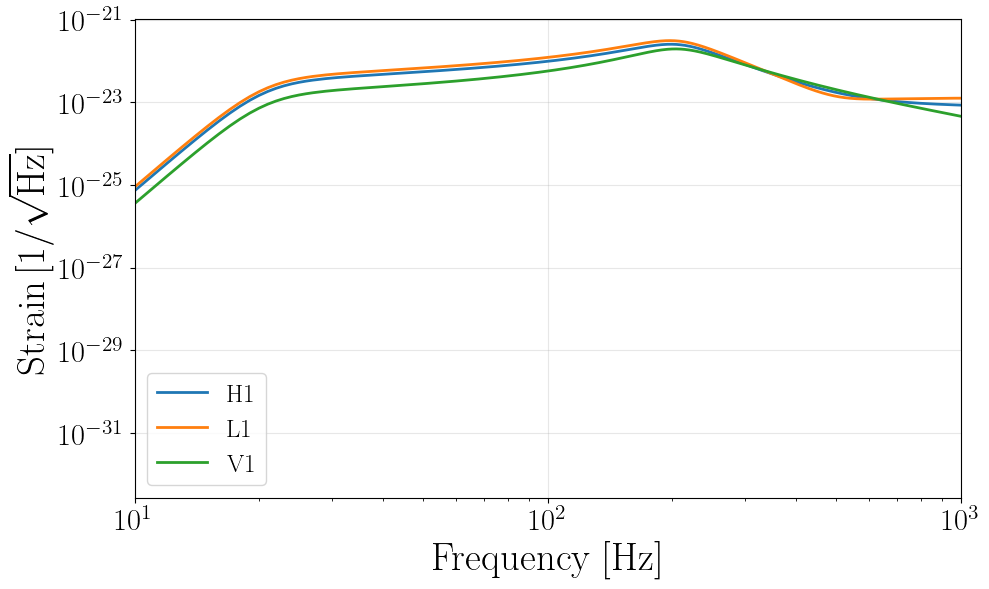


--- Antenna Pattern Check ---
[H1]
  LAL   : F+=-0.3814, Fx=0.5945
[L1]
  LAL   : F+=0.6109, Fx=-0.5707
[V1]
  LAL   : F+=0.0439, Fx=0.5454


In [40]:
# label = 'shiftIm_to_220_dw0.3w1_snr100_OTparam'
# label = 'shiftRe_to_220_dw0.3w1_snr100_OTparam'
# label = 'shiftIm_to_220_dw0.1w1_snr100_OTparam'
# label = 'shiftIm_to_220_dw0.01w1_snr100_OTparam'
# label = 'shiftIm_to_220_dw0.001w1_snr100_OTparam'
# label = 'shiftRe_to_220_dw0.1w1_snr100_OTparam'
# label = 'shiftRe_to_220_dw0.01w1_snr100_OTparam'
# label = 'shiftRe_to_220_dw0.001w1_snr100_OTparam'

# label = 'shiftIm_to_220_dw0.3w1_snr100_DSparam'
# label = 'shiftRe_to_220_dw0.3w1_snr100_DSparam'
# label = 'shiftIm_to_220_dw0.1w1_snr100_DSparam'
# label = 'shiftIm_to_220_dw0.01w1_snr100_DSparam'
# label = 'shiftIm_to_220_dw0.001w1_snr100_DSparam'
# label = 'shiftRe_to_220_dw0.1w1_snr100_DSparam'
# label = 'shiftRe_to_220_dw0.01w1_snr100_DSparam'
# label = 'shiftRe_to_220_dw0.001w1_snr100_DSparam'

# label = 'shiftIm_to_220_dw0.3w1_snr100_EPparam'
# label = 'shiftRe_to_220_dw0.3w1_snr100_EPparam'
# label = 'shiftIm_to_220_dw0.1w1_snr100_EPparam'
# label = 'shiftIm_to_220_dw0.01w1_snr100_EPparam'
# label = 'shiftIm_to_220_dw0.001w1_snr100_EPparam'
# label = 'shiftRe_to_220_dw0.1w1_snr100_EPparam'
# label = 'shiftRe_to_220_dw0.01w1_snr100_EPparam'
# label = 'shiftRe_to_220_dw0.001w1_snr100_EPparam'

# label = '220_221_snr100_OTparam'
label = '220_221_snr100_DSparam'
# label = '220_221_snr100_EPparam'

# label = 'shift45deg_to_220_dw0.1w1_snr100_OTparam'
# label = 'shift45deg_to_220_dw0.01w1_snr100_OTparam'
# label = 'shift45deg_to_220_dw0.001w1_snr100_OTparam'
# label = 'shift45deg_to_220_dw0.1w1_snr100_DSparam'
# label = 'shift45deg_to_220_dw0.01w1_snr100_DSparam'
# label = 'shift45deg_to_220_dw0.001w1_snr100_DSparam'
# label = 'shift45deg_to_220_dw0.1w1_snr100_EPparam'
# label = 'shift45deg_to_220_dw0.01w1_snr100_EPparam'
# label = 'shift45deg_to_220_dw0.001w1_snr100_EPparam'

# label = 'a0.9_225_226_snr100_OTparam'
# label = 'a0.9_225_226_snr100_DSparam'
# label = 'a0.9_225_226_snr100_EPparam'


config_file_pyring = f'./run_pyring/config/pyring_{label}.ini'

inject_pyring_waveform(config_file_pyring=config_file_pyring, plot_EP=True)